In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA


In [2]:
df = pd.read_csv("../data/processed/japan_feature_engineered.csv")

df.head()


,Year,Total_Population,Elderly_Percent,GDP,Fertility_Rate,Elderly_Population,Working_Age_Population,Dependency_Ratio,GDP_Per_Capita,Population_Growth_Rate,Elderly_scaled,Dependency_scaled,PopGrowth_scaled,Demographic_Risk_Score
0,1990,123478000.0,12.159237,3.185905e+12,1.54,1.501398e+07,1.084640e+08,0.138424,25801.395039,NaN,0.000000,0.000000,NaN,NaN
1,1991,123964000.0,12.642663,3.648066e+12,1.53,1.567235e+07,1.082916e+08,0.144724,29428.428904,0.003936,0.027434,0.022052,1.000000,1.979421
2,1992,124425000.0,13.146100,3.980703e+12,1.50,1.635703e+07,1.080680e+08,0.151359,31992.790212,0.003719,0.056003,0.045277,0.975323,4.544757
3,1993,124829000.0,13.645147,4.536940e+12,1.46,1.703310e+07,1.077959e+08,0.158013,36345.244126,0.003247,0.084324,0.068567,0.921686,7.681918
4,1994,125178000.0,14.147171,4.998798e+12,1.50,1.770915e+07,1.074689e+08,0.164784,39933.515056,0.002796,0.112813,0.092270,0.870411,10.795092


In [3]:
risk_series = df.set_index("Year")["Demographic_Risk_Score"]

risk_series.head()


Year
1990          NaN
1991     1.979421
1992     4.544757
1993     7.681918
1994    10.795092
Name: Demographic_Risk_Score, dtype: float64

In [4]:
model = ARIMA(risk_series, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())


                                 SARIMAX Results                                  
Dep. Variable:     Demographic_Risk_Score   No. Observations:                   35
Model:                     ARIMA(1, 1, 1)   Log Likelihood                 -72.090
Date:                    Mon, 16 Feb 2026   AIC                            150.180
Time:                            12:59:56   BIC                            154.759
Sample:                                 0   HQIC                           151.742
                                     - 35                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.003    313.691      0.000       0.994       1.006
ma.L1         -0.9950      2.132     -0.467      0.641      -5.174       3.184
sigma2         2.506

c:\projects\japan_crisis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\projects\japan_crisis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\projects\japan_crisis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [5]:
forecast_steps = 26

forecast_result = model_fit.get_forecast(steps=forecast_steps)

forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

last_year = df["Year"].max()
future_years = [last_year + i for i in range(1, forecast_steps + 1)]


c:\projects\japan_crisis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\projects\japan_crisis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


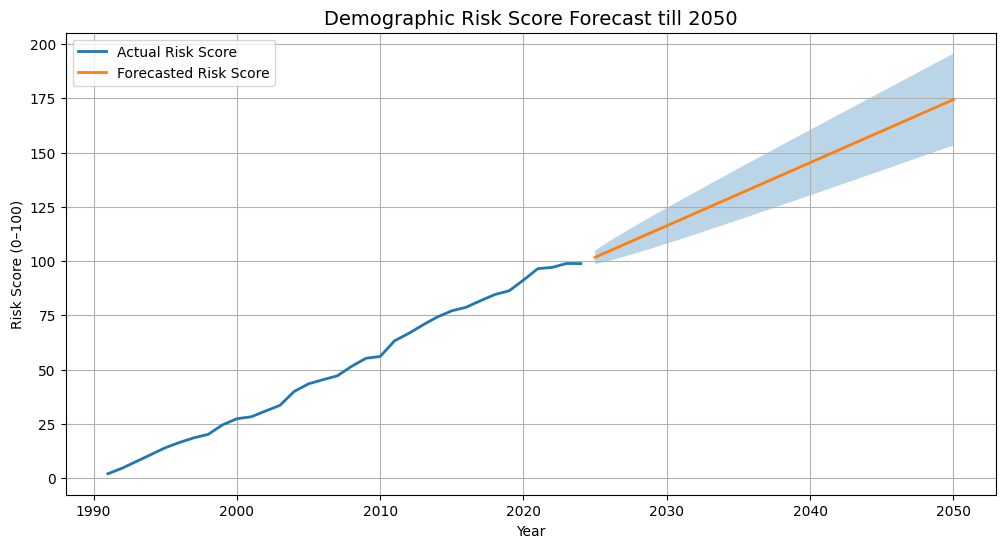

In [6]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Year"],
    df["Demographic_Risk_Score"],
    label="Actual Risk Score",
    linewidth=2
)

plt.plot(
    future_years,
    forecast_mean,
    label="Forecasted Risk Score",
    linewidth=2
)

plt.fill_between(
    future_years,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.3
)

plt.title("Demographic Risk Score Forecast till 2050", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Risk Score (0–100)")
plt.legend()
plt.grid(True)

plt.show()


## 📌 Risk Forecast Insight

The projected Demographic Risk Score shows a continued increase 
through 2050, indicating intensifying economic burden due to 
population aging and workforce decline.

If no structural interventions are implemented, 
Japan’s demographic crisis may significantly impact long-term economic stability.
